# 자율이동체 시스템 중간 대체 과제
20231411 이의진

# 문제 1. Projection Matrix 해석

**1. Projection Matrix란?**
KITTI 데이터셋의 calib.txt에 포함된 $P$ 행렬은 3차원 공간의 점을 2차원 이미지 픽셀 좌표로 변환해 주는 $3 \times 4$ 투영 행렬(Projection Matrix)이다. 일반적으로 투영 행렬은 $P = K[R|t]$ 형태로 표현되지만, Sequence 09의 왼쪽 흑백 카메라 기준 행렬($P_0$)은 다음과 같다.

$$P_0 = \begin{bmatrix} 707.0912 & 0 & 601.8873 & 0 \\ 0 & 707.0912 & 183.1104 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix}$$

KITTI의 기준 카메라인 $P_0$의 경우 카메라 좌표계 자체를 원점(Reference)으로 하므로 외부 파라미터가 $R=I$, $t=0$인 형태로 단순화된 특수한 경우이다.

<br>

**2. Intrinsic 파라미터 ($K$)**
$P_0$ 행렬의 좌측 $3 \times 3$ 부분은 카메라 내부의 광학적 특성을 나타내는 Intrinsic 파라미터이다.

$f_x$ (수평 초점 거리, Focal length): 707.0912 px

$f_y$ (수직 초점 거리): 707.0912 px

$c_x$ (주점의 수평 위치, Principal point): 601.8873 px

$c_y$ (주점의 수직 위치): 183.1104 px

[해석]
$f_x = f_y$로 동일하므로, 이미지 센서가 정방형 픽셀(Square pixel)을 가짐을 알 수 있다. 주점 $(c_x, c_y) = (601.89, 183.11)$은 KITTI 이미지 해상도($1241 \times 376$)를 기준으로 할 때, 수평 및 수직 방향 모두 전체 해상도의 거의 중앙에 위치한다. 즉, 렌즈의 광학 축이 이미지 센서의 정중앙을 올바르게 통과하고 있음을 확인할 수 있다.

<br>

**3. Extrinsic 파라미터 ($[R|t]$)**
기준 카메라($P_0$) 자체에는 외부 파라미터가 드러나지 않으므로, 차량(LiDAR) 좌표계에서 카메라 좌표계로의 3차원 변환을 나타내는 calib.txt의 $Tr$ (Tr_velo_to_cam) 행렬을 통해 해석할 수 있다.

$$Tr = \begin{bmatrix}
-0.001858 & -0.999966 & -0.008040 & -0.004784 \
-0.006481 & 0.008052 & -0.999947 & -0.073374 \
0.999977 & -0.001806 & -0.006496 & -0.333997
\end{bmatrix}$$

$R$ (좌측 $3 \times 3$ 행렬, 회전): KITTI에서 LiDAR 좌표계는 (X: 전방, Y: 좌측, Z: 상단)이고, 카메라 좌표계는 (X: 우측, Y: 하단, Z: 전방)이다. 이 회전 행렬은 센서 간의 축 정의가 서로 약 90도씩 틀어져 있는 것을 카메라 뷰에 맞게 보정하는 역할을 한다.

$t$ (우측 $3 \times 1$ 벡터, 평행 이동): $t = (-0.00478, -0.07337, -0.33400)^T$ (단위: m)이다. 이를 해석하면 카메라 좌표계 기준으로 볼 때 LiDAR 센서가 카메라보다 약 33.4cm 뒤쪽(-Z), 7.3cm 위쪽(-Y)에 장착되어 있다는 물리적 배치 구조를 의미한다.

<br>

**4. 3D $\rightarrow$ 2D 투영 수식 해석**
3차원 카메라 좌표계의 점 $\mathbf{X} = (X, Y, Z)^T$가 2차원 이미지 좌표 $(u, v)$로 변환되는 과정은 다음과 같다.

1단계: 동차 좌표계(Homogeneous Coordinates) 표현
3차원 점의 끝에 1을 추가하여 차원을 확장한 $\tilde{\mathbf{X}} = (X, Y, Z, 1)^T$ 로 만든다.

2단계: Projection Matrix 적용
$P_0$ 행렬과 곱하여 카메라 센서 평면상에 투영된 좌표 $\tilde{\mathbf{x}}$를 구한다.


$$\tilde{\mathbf{x}} = P_0 \cdot \tilde{\mathbf{X}} = \begin{bmatrix} 707.0912 \cdot X + 601.8873 \cdot Z \\ 707.0912 \cdot Y + 183.1104 \cdot Z \\ Z \end{bmatrix}$$

3단계: 정규화 (원근 나눗셈, Perspective Division)
마지막 요소인 $Z$(카메라로부터의 깊이 혹은 거리)로 앞의 두 요소를 나누어 최종 픽셀 좌표 $(u, v)$를 얻는다.


$$u = \frac{707.0912 \cdot X}{Z} + 601.8873$$

$$v = \frac{707.0912 \cdot Y}{Z} + 183.1104$$

[해석] 위 수식에서 물체의 거리($Z$값)가 무한히 커질수록 $\frac{X}{Z}$ 와 $\frac{Y}{Z}$ 항은 0에 수렴하게 된다. 결과적으로 아주 멀리 있는 점은 이미지의 주점 $(u, v) \approx (601.89, 183.11)$ 방향으로 모이게 된다. 이는 3차원 공간에서 평행한 차선들이 이미지 상에서는 한 점으로 모이는 원근 투영(Perspective projection)의 소실점(Vanishing point) 특성을 수학적으로 증명하며, 앞선 베이지안 분류기에서 도로 영역을 사다리꼴(위쪽이 좁아지는 형태)로 가정한 논리적 근거가 된다.

# 문제 2. Projection Matrix를 이용한 3D $\rightarrow$ 2D 투영


전체 점: 50개, 이미지 내 점: 47개


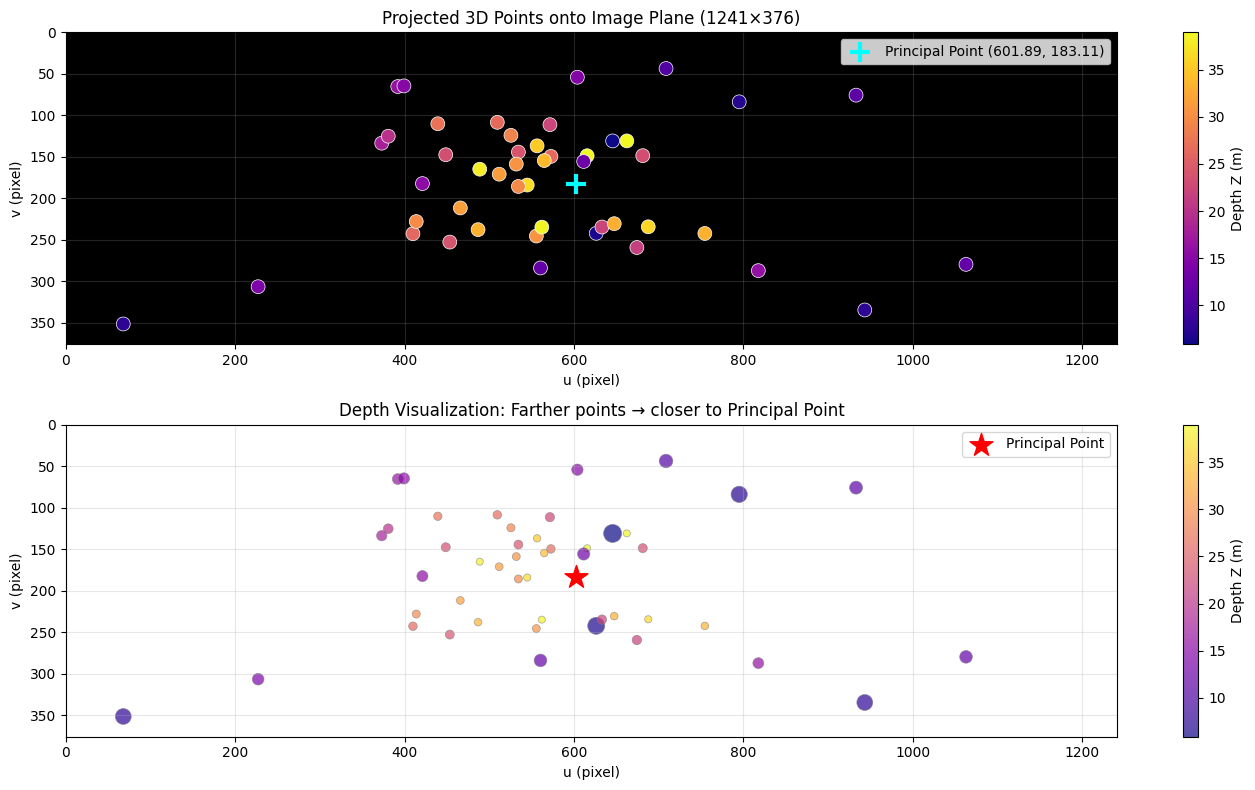

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path

# Sequence 09의 P0 행렬
P0 = np.array([
    [707.0912, 0,        601.8873, 0],
    [0,        707.0912, 183.1104, 0],
    [0,        0,        1,        0]
])

# 임의의 3D 점 생성 (카메라 좌표계 기준)
# X: 좌우, Y: 상하, Z: 전방 (Z > 0 이어야 카메라 앞에 있음)
np.random.seed(42)
num_points = 50

points_3d = np.random.uniform(
    low= [-8,  -3, 5],   # X, Y, Z 최솟값
    high=[ 8,   3, 40],  # X, Y, Z 최댓값
    size=(num_points, 3)
)

# 동차 좌표로 변환 (N x 4)
ones = np.ones((num_points, 1))
points_homo = np.hstack([points_3d, ones])  # (N, 4)

# P0 행렬로 투영 (3 x 4) @ (4 x N)
projected = (P0 @ points_homo.T)  # (3, N)

# 원근 나눗셈 (Z로 나누기)
u = projected[0] / projected[2]
v = projected[1] / projected[2]
z = points_3d[:, 2]  # 깊이값 (색상에 활용)

# 이미지 범위 내에 있는 점만 필터링 (1241 x 376)
img_w, img_h = 1241, 376
valid = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
u_valid = u[valid]
v_valid = v[valid]
z_valid = z[valid]

print(f"전체 점: {num_points}개, 이미지 내 점: {valid.sum()}개")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- 상단: 이미지 위에 투영된 점 표시 ---
ax1 = axes[0]
ax1.set_facecolor('black')
ax1.set_xlim(0, img_w)
ax1.set_ylim(img_h, 0)  # 이미지 좌표계 (y축 반전)

sc = ax1.scatter(u_valid, v_valid, c=z_valid, cmap='plasma',
                 s=100, zorder=5, edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=ax1, label='Depth Z (m)')

# 주점 표시
ax1.scatter(601.8873, 183.1104, c='cyan', s=200, marker='+',
            linewidths=3, zorder=10, label='Principal Point (601.89, 183.11)')

ax1.set_xlabel('u (pixel)')
ax1.set_ylabel('v (pixel)')
ax1.set_title('Projected 3D Points onto Image Plane (1241×376)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

# --- 하단: 깊이(Z)에 따른 투영 위치 산점도 ---
ax2 = axes[1]
sc2 = ax2.scatter(u_valid, v_valid, c=z_valid, cmap='plasma',
                  s=1000/z_valid, alpha=0.7, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc2, ax=ax2, label='Depth Z (m)')

ax2.scatter(601.8873, 183.1104, c='red', s=300, marker='*',
            zorder=10, label='Principal Point')
ax2.set_xlim(0, img_w)
ax2.set_ylim(img_h, 0)
ax2.set_xlabel('u (pixel)')
ax2.set_ylabel('v (pixel)')
ax2.set_title('Depth Visualization: Farther points → closer to Principal Point')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('projection_result.png', dpi=150, bbox_inches='tight')
plt.show()

**1. 투영 과정 구현 (3D $\rightarrow$ 2D)**

Sequence 09의 $P_0$ 행렬을 이용하여 카메라 좌표계 기준으로 임의의 3D 점 50개를 생성하고 투영하는 코드를 구현하였다.

3D 점 생성 범위: 차량 전방의 다양한 환경을 모사하기 위해 각 점은 $X \in [-8, 8]\text{m}$ (좌우), $Y \in [-3, 3]\text{m}$ (상하), $Z \in [5, 40]\text{m}$ (전방 깊이) 범위로 설정하였으며, $Z > 0$ 조건을 통해 카메라 전방에 위치한 점들만 생성하였다.

투영 연산: 생성된 3차원 점을 동차 좌표계(Homogeneous coordinates)로 변환 후 $P_0$ 행렬과 곱셈 연산을 수행하였다. 이후 깊이 값인 $Z$로 좌표를 나누는 원근 나눗셈(Perspective Division)을 적용하여 최종 2D 픽셀 좌표 $(u, v)$를 산출하였다.

<br>

**2. 카메라 투영 특성과의 일치성 분석**

위의 투영 결과를 시각화한 이미지를 살펴보면, 실제 카메라의 핀홀(Pinhole) 기하학적 특성이 완벽하게 반영되어 있음을 알 수 있다.

첫째, 원근 수렴(Perspective Convergence) 특성이다. 시각화 결과에서 깊이 $Z$가 큰 점(노란색 계열, 약 35~ 40m)일수록 이미지의 주점(Principal Point, $(601.89, 183.11)$) 근처에 조밀하게 밀집되며, 카메라와 가까운 점(보라색 계열, 약 5~10m)일수록 이미지 가장자리로 넓게 분산된다.
수식 $u = f_x \cdot \frac{X}{Z} + c_x$, $v = f_y \cdot \frac{Y}{Z} + c_y$ 에 따르면, $Z \to \infty$로 커질수록 $\frac{X}{Z} \to 0, \frac{Y}{Z} \to 0$이 되어 결과적으로 $(u, v) \to (c_x, c_y)$ 로 수렴한다. Z축과 평행하게 뻗어있는 점들은 궁극적으로 주점을 소실점(Vanishing Point)으로 삼아 모이게 되며, 시각화 결과는 이 수학적 사실을 정확히 증명한다.

둘째, 거리 기반 시각적 크기(Scale)의 변화이다. 하단 시각화 그래프에서 투영된 점의 크기를 깊이 $Z$에 반비례하도록 설정했을 때, 가까운 점은 뚜렷하고 크게, 먼 점은 작게 나타난다. 투영 행렬 연산 자체가 3차원 공간의 스케일을 2차원으로 압축하는 과정이므로, 원근에 따라 물체의 픽셀 크기가 작아지는 실제 카메라의 원리를 직관적으로 보여준다.

셋째, 유한한 화각(Field of View, FOV)에 따른 필터링 효과이다. 임의로 생성된 50개의 점들 중에서 투영된 좌표 $(u, v)$가 실제 센서 해상도($1241 \times 376$)를 벗어나는 점들은 카메라 렌즈의 시야각 범위를 벗어난 물체임을 의미한다. 투영 결과가 센서 배열(Sensor Array)의 경계 내에 맺혀야만 이미지로 관측될 수 있다는 카메라 시스템의 물리적 한계를 잘 보여준다.

# 문제 3. Pose를 이용한 차량 궤적 시각화

총 프레임 수: 1591
총 이동 거리: 1705.1 m
평균 속도: 37.2 km/h
최고 속도: 53.6 km/h


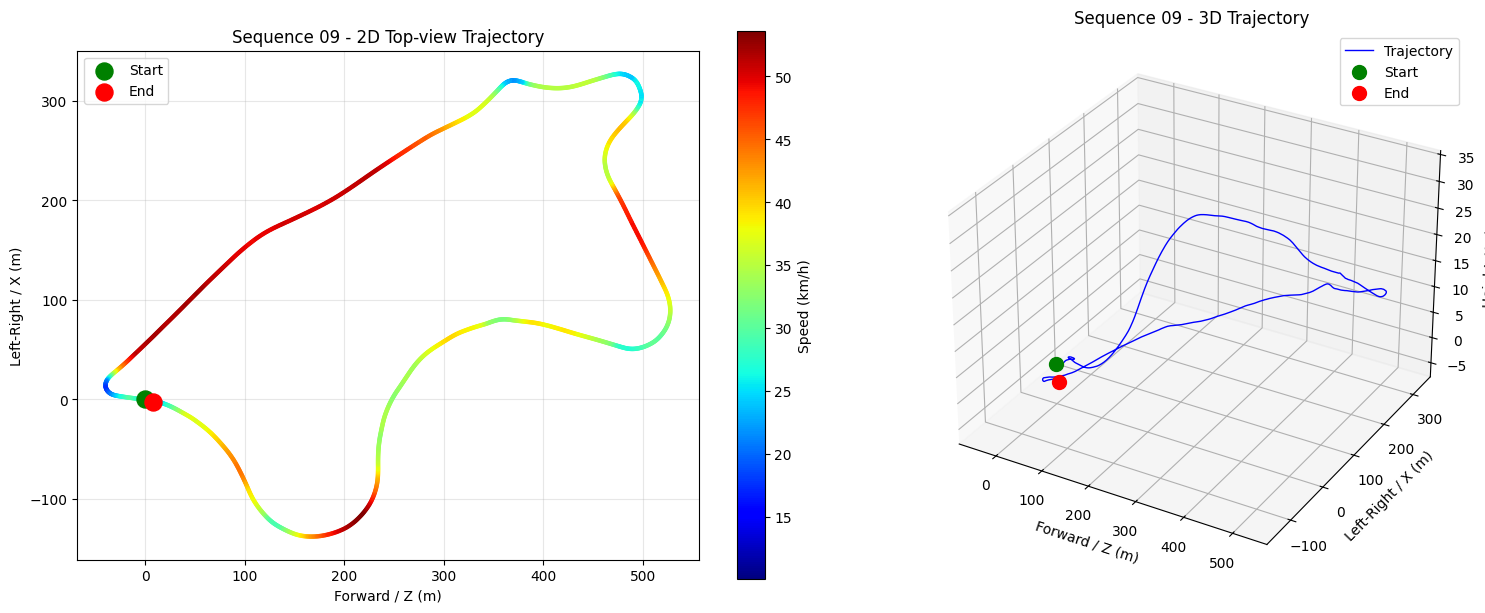

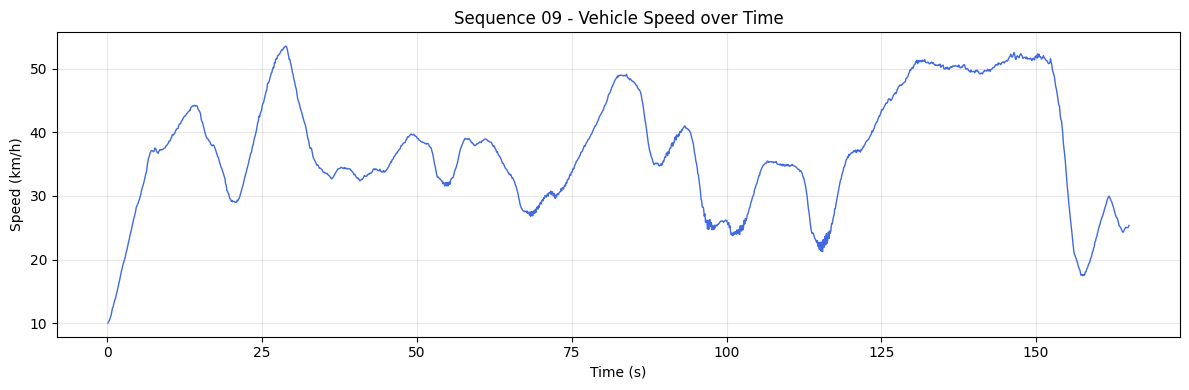

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Sequence 09 poses 로드
poses = []
with open('09.txt', 'r') as f:
    for line in f.readlines():
        T = np.fromstring(line, dtype=float, sep=' ')
        T = T.reshape(3, 4)
        poses.append(T)

# 각 프레임의 카메라 위치 추출 (translation 벡터)
positions = np.array([p[:, 3] for p in poses])  # (N, 3)

# 초기 프레임을 기준 좌표계로 설정 (첫 번째 위치를 원점으로)
origin = positions[0].copy()
positions = positions - origin

x = positions[:, 0]  # 좌우
y = positions[:, 1]  # 상하 (높이)
z = positions[:, 2]  # 전진

# times.txt 로드 (속도 계산용)
times = []
with open('times.txt', 'r') as f:
    for line in f.readlines():
        times.append(float(line.strip()))
times = np.array(times)

# 프레임 간 이동 거리 및 속도 계산
dists = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
dt = np.diff(times)
speeds = dists / dt * 3.6  # m/s → km/h

print(f"총 프레임 수: {len(poses)}")
print(f"총 이동 거리: {dists.sum():.1f} m")
print(f"평균 속도: {speeds.mean():.1f} km/h")
print(f"최고 속도: {speeds.max():.1f} km/h")

# ── 시각화 ──
fig = plt.figure(figsize=(16, 6))

# --- 2D 궤적 (Top-view) ---
ax1 = fig.add_subplot(121)
speeds_plot = np.concatenate([[speeds[0]], speeds])  # 1590 → 1591개
sc = ax1.scatter(z, x, c=speeds_plot, cmap='jet', s=5, zorder=3)
plt.colorbar(sc, ax=ax1, label='Speed (km/h)')
ax1.plot(z, x, color='gray', linewidth=0.5, alpha=0.5, zorder=2)
ax1.scatter(z[0], x[0], color='green', s=150, zorder=5, label='Start')
ax1.scatter(z[-1], x[-1], color='red', s=150, zorder=5, label='End')
ax1.set_xlabel('Forward / Z (m)')
ax1.set_ylabel('Left-Right / X (m)')
ax1.set_title('Sequence 09 - 2D Top-view Trajectory')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# --- 3D 궤적 ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(z, x, -y, color='blue', linewidth=1, label='Trajectory')
ax2.scatter(z[0], x[0], -y[0], color='green', s=100, label='Start')
ax2.scatter(z[-1], x[-1], -y[-1], color='red', s=100, label='End')
ax2.set_xlabel('Forward / Z (m)')
ax2.set_ylabel('Left-Right / X (m)')
ax2.set_zlabel('Height / Y (m)')
ax2.set_title('Sequence 09 - 3D Trajectory')
ax2.legend()

plt.tight_layout()
plt.savefig('trajectory_09.png', dpi=150, bbox_inches='tight')
plt.show()

# 속도 그래프
fig2, ax3 = plt.subplots(figsize=(12, 4))
ax3.plot(times[1:], speeds, color='royalblue', linewidth=1)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Speed (km/h)')
ax3.set_title('Sequence 09 - Vehicle Speed over Time')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('speed_09.png', dpi=150, bbox_inches='tight')
plt.show()

**1. 궤적 추출 및 시각화 개요**

KITTI 데이터셋 Sequence 09의 Ground Truth Pose 데이터(09.txt)를 이용하여 총 1,591개 프레임에 대한 차량(카메라)의 이동 궤적을 추출 및 시각화하였다. 각 행렬의 평행 이동(Translation) 벡터를 추출한 뒤, 초기 프레임의 위치를 기준 좌표계의 원점 $(0, 0, 0)$으로 설정하여 이후 모든 프레임의 좌표를 상대적인 이동 경로로 변환하였다.

시각화는 2D 탑뷰(Top-view)와 3D 그래프 두 가지 방식으로 구성하였다. 특히 2D 탑뷰에서는 각 구간의 색상을 산출된 주행 속도에 비례하도록 매핑(Color mapping)하여 주행 특성을 한눈에 파악할 수 있도록 하였다.

<br>

**2. 차량 이동 방향 및 공간 분석**

2D 탑뷰 및 3D 궤적 그래프를 분석한 결과, 차량은 출발점(Start, 녹색 점)에서 전진 방향($Z$축)으로 주행을 시작하여 우회전 및 좌회전을 거치며 거대한 루프(Loop) 형태의 경로를 그린다. 이후 주행을 마치고 종료점(End, 빨간 점)이 다시 출발점 근처로 되돌아오는 거대한 폐곡선 형태의 이동 궤적을 보인다.
전체 누적 이동 거리는 약 1,705m이며, 주행 공간의 범위는 기준점으로부터 전진($Z$) 방향으로 약 500m, 좌우($X$) 방향으로 약 400m에 걸쳐 분포해 있다.
특히 3D 궤적 시각화 시, KITTI 카메라 좌표계의 $Y$축이 하단(Down)을 향하는 특성을 고려하여 높이 축을 $-y$로 반전시킴으로써 실제 지형의 고도 변화를 직관적으로 확인할 수 있도록 구현하였다.

<br>

**3. 차량 속도 및 주행 패턴 분석**

궤적의 공간적 정보뿐만 아니라 동적인 주행 특성을 분석하기 위해 times.txt 파일의 실제 타임스탬프 데이터를 활용하였다. 각 프레임 간의 3차원 이동 거리($\Delta d$)와 시간 차이($\Delta t$)를 이용하여 구간별 순간 속도(km/h)를 산출하였다.

분석 결과, 해당 Sequence의 평균 주행 속도는 약 37.2 km/h, 최고 속도는 53.6 km/h로 측정되었다. 2D 탑뷰 그래프의 속도 매핑 결과를 보면, 긴 직선 주행 구간(빨간색/주황색 계열, 약 40~ 50km/h)에서는 가속 및 항속 주행이 이루어졌고, 급격한 코너링 구간(초록색/파란색 계열, 약 20~30km/h 이하)에서는 안정적인 회전을 위해 확연하게 감속이 이루어졌음을 시각적으로 확인할 수 있다. 이는 교차로 회전 및 곡선 도로에서 감속하는 실제 차량의 도심지 주행 물리 모델과 정확히 일치하는 결과이다.

# 문제 4. Projection Matrix를 활용한 차선 해석

In [13]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
from PIL import Image
import cv2
import math

# ── 교수님 제공 함수들 ──

def list_frames(data_root: Path):
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width, height, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img, mask):
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img, road_p, bg_p, prior_road):
    eps = 1e-10
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)
    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(data_root, train_frames, save_frames, out_dir,
        prior_road, alpha=0.85, video_path=None, video_fps=10.0,
        vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15,
        max_frames=None):

    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape

    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask

    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    frames_iter = frames[:limit]

    writer = None
    if video_path is not None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)

        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)

        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)

        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        should_save = (save_frames < 0 or idx < save_frames or writer is not None)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        if idx % 100 == 0:
            print(f"[{idx}/{len(frames_iter)}] 처리 중")

    if writer is not None:
        writer.release()
    print("완료")

# ── 실행 ──
run(
    data_root=Path('/content/drive/MyDrive/mid_term/image_0'),
    train_frames=80,
    save_frames=-1,
    out_dir=Path('/content/outputs/bayes_road'),
    prior_road=0.5,
    alpha=0.85,
    video_path=Path('/content/outputs/bayes_road.mp4'),
    video_fps=10.0,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[0/1591] 처리 중
[100/1591] 처리 중
[200/1591] 처리 중
[300/1591] 처리 중
[400/1591] 처리 중
[500/1591] 처리 중
[600/1591] 처리 중
[700/1591] 처리 중
[800/1591] 처리 중
[900/1591] 처리 중
[1000/1591] 처리 중
[1100/1591] 처리 중
[1200/1591] 처리 중
[1300/1591] 처리 중
[1400/1591] 처리 중
[1500/1591] 처리 중
완료


In [14]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
from PIL import Image
import cv2
import math
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 경로 설정
IMG_DIR   = Path('/content/drive/MyDrive/mid_term/image_0')
CALIB_TXT = Path('/content/drive/MyDrive/mid_term/calib.txt')

# calib 파싱
with open(CALIB_TXT) as f:
    for line in f:
        if line.startswith('P0:'):
            vals = list(map(float, line.split()[1:]))
            P0 = np.array(vals).reshape(3, 4)

fx = P0[0,0]; fy = P0[1,1]
cx = P0[0,2]; cy = P0[1,2]
print(f"fx={fx}, fy={fy}, cx={cx}, cy={cy}")

frame_files = sorted(IMG_DIR.glob("*.png"))
sample = np.array(Image.open(frame_files[0]).convert("L"))
H, W = sample.shape
print(f"이미지 크기: {W}×{H}, 총 프레임: {len(frame_files)}개")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fx=707.0912, fy=707.0912, cx=601.8873, cy=183.1104
이미지 크기: 1226×370, 총 프레임: 1591개


In [15]:
def get_trapezoid_mask(width, height, vp_y_rate=0.55,
                        bw=0.65, tw=0.08):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    pts = np.array([
        [int(width*(0.5-tw)),   vp_y],
        [int(width*(0.5+tw)),   vp_y],
        [int(width*(0.5+bw/2)), height],
        [int(width*(0.5-bw/2)), height],
    ], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def build_bayesian_model(frames, n_train=80, alpha=0.85):
    sample = np.array(Image.open(frames[0]).convert("L"))
    h, w = sample.shape
    road_mask = get_trapezoid_mask(w, h)
    bg_mask   = 1 - road_mask

    road_h = np.ones(256)
    bg_h   = np.ones(256)

    for i, fp in enumerate(frames[:n_train]):
        img = np.array(Image.open(fp).convert("L"), dtype=np.uint8)
        rc = np.bincount(img[road_mask>0].ravel(), minlength=256).astype(np.float64)
        bc = np.bincount(img[bg_mask>0].ravel(),   minlength=256).astype(np.float64)
        if i == 0:
            road_h = rc + 1; bg_h = bc + 1
        else:
            road_h = alpha*road_h + (1-alpha)*(rc+1)
            bg_h   = alpha*bg_h   + (1-alpha)*(bc+1)

    # 노이즈 제거용 커널
    kernel = np.ones((5,5), np.uint8)
    return road_h/road_h.sum(), bg_h/bg_h.sum(), kernel

def classify(img, road_p, bg_p, prior=0.35):
    eps = 1e-10
    logit = (np.log(road_p[img]+eps) - np.log(bg_p[img]+eps)
             + math.log(prior) - math.log(1-prior))
    prob = 1 / (1 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    # 노이즈 제거
    mask_u8 = mask.astype(np.uint8)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN,  np.ones((5,5),np.uint8))
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8))
    return mask_u8.astype(bool), prob

road_p, bg_p, kernel = build_bayesian_model(frame_files, n_train=80)
print("Bayesian 모델 학습 완료")

Bayesian 모델 학습 완료


Hough lines after filter: 21
Estimated VP:  (586.3, 174.1)
Principal pt:  (601.9, 183.1)
VP error from cx: 15.6 px
Back-projected points: 140


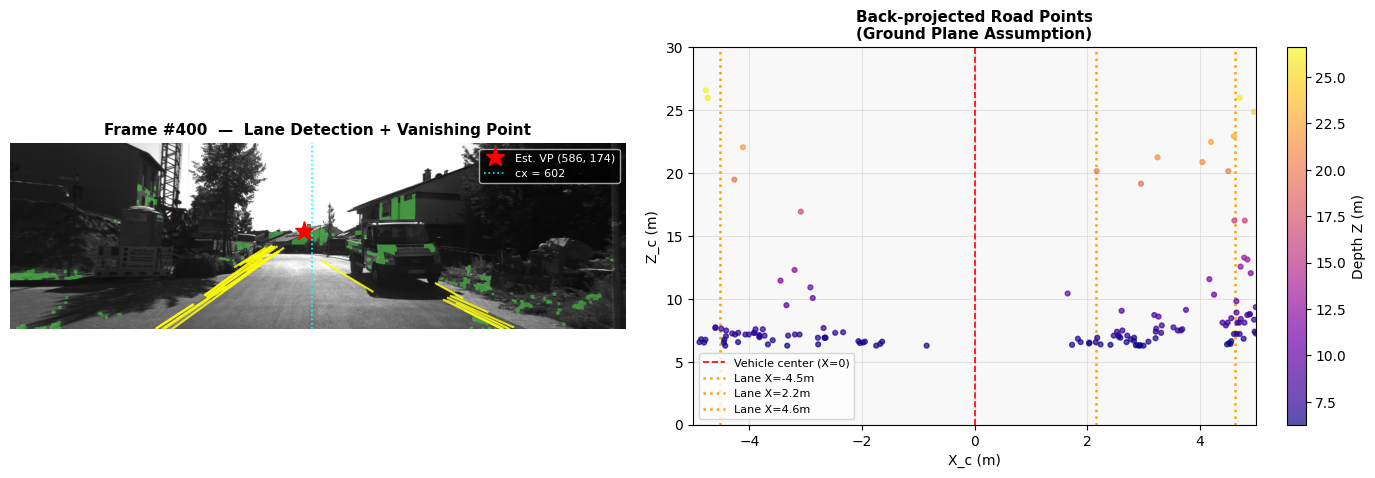

Saved: q4_lane_projection.png


In [16]:
TARGET_FRAME = 400
img_t = np.array(Image.open(frame_files[TARGET_FRAME]).convert("L"), dtype=np.uint8)
road_binary, road_prob = classify(img_t, road_p, bg_p)


roi_mask = get_trapezoid_mask(W, H)
lower_roi = np.zeros((H, W), dtype=np.uint8)
lower_roi[H//2:, :] = 1
combined_roi = cv2.bitwise_and(roi_mask, lower_roi)

# Canny + Hough
edges = cv2.Canny(img_t, 50, 150)
edges_roi = cv2.bitwise_and(edges, edges, mask=combined_roi)
lines_raw = cv2.HoughLinesP(edges_roi, 1, np.pi/180, 40,
                             minLineLength=50, maxLineGap=15)
lines = []
if lines_raw is not None:
    for l in lines_raw:
        x1,y1,x2,y2 = l[0]
        if abs(x2-x1) > 1e-3:
            slope = (y2-y1)/(x2-x1)
            if 0.4 < abs(slope) < 5.0:
                lines.append(l)

print(f"Hough lines after filter: {len(lines)}")

# 소실점 계산
def line_to_eq(x1,y1,x2,y2):
    a=y2-y1; b=x1-x2; c=a*x1+b*y1
    return a,b,c

vp_candidates = []
for i in range(len(lines)):
    for j in range(i+1, len(lines)):
        x1,y1,x2,y2 = lines[i][0]
        x3,y3,x4,y4 = lines[j][0]
        a1,b1,c1 = line_to_eq(x1,y1,x2,y2)
        a2,b2,c2 = line_to_eq(x3,y3,x4,y4)
        det = a1*b2 - a2*b1
        if abs(det) > 1e-6:
            vx=(c1*b2-c2*b1)/det
            vy=(a1*c2-a2*c1)/det
            if W*0.2 < vx < W*0.8 and 0 < vy < H*0.7:
                vp_candidates.append((vx,vy))

vp_est = (np.median(vp_candidates, axis=0)
          if len(vp_candidates) > 3
          else np.array([cx, H*0.45]))
print(f"Estimated VP:  ({vp_est[0]:.1f}, {vp_est[1]:.1f})")
print(f"Principal pt:  ({cx:.1f}, {cy:.1f})")
print(f"VP error from cx: {abs(vp_est[0]-cx):.1f} px")

# 역투영
h_cam = 1.65
road_pixels = np.argwhere(road_prob > 0.25)
X_c = np.array([]); Z_c = np.array([])
if len(road_pixels) > 0:
    idx = np.random.choice(len(road_pixels),
                           min(600, len(road_pixels)), replace=False)
    sampled = road_pixels[idx]
    u_px = sampled[:,1].astype(np.float64)
    v_px = sampled[:,0].astype(np.float64)
    valid = (v_px - cy) > 15
    u_v = u_px[valid]; v_v = v_px[valid]
    Zc = fy * h_cam / (v_v - cy)
    Xc = (u_v - cx) * Zc / fx
    filt = (Zc>0)&(Zc<30)&(np.abs(Xc)<5)
    X_c = Xc[filt]; Z_c = Zc[filt]
    print(f"Back-projected points: {len(Z_c)}")

# ── 시각화: 1x2 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# (A) 원본 + 차선 검출
ax = axes[0]
vis = np.stack([img_t]*3, axis=-1)
vis_copy = vis.copy()
vis_copy[road_binary, 1] = np.clip(
    vis_copy[road_binary,1].astype(int) + 80, 0, 255).astype(np.uint8)
ax.imshow(vis_copy)
for l in lines:
    x1,y1,x2,y2 = l[0]
    ax.plot([x1,x2],[y1,y2], color='yellow', linewidth=1.5, alpha=0.85)
ax.plot(*vp_est, 'r*', markersize=14, zorder=6,
        label=f'Est. VP ({vp_est[0]:.0f}, {vp_est[1]:.0f})')
ax.axvline(cx, color='cyan', linestyle=':', linewidth=1.2,
           label=f'cx = {cx:.0f}')
ax.set_title(f'Frame #{TARGET_FRAME}  —  Lane Detection + Vanishing Point',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right',
          facecolor='black', labelcolor='white')
ax.axis('off')

# (B) 역투영 XZ
ax = axes[1]
ax.set_facecolor('#f8f8f8')
if len(Z_c) > 0:
    sc = ax.scatter(X_c, Z_c, c=Z_c, cmap='plasma',
                    s=12, alpha=0.7, zorder=3)
    plt.colorbar(sc, ax=ax, label='Depth Z (m)', fraction=0.035)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
           label='Vehicle center (X=0)')

if len(X_c) > 10:
    hist_v, bin_e = np.histogram(X_c, bins=40)
    bin_c = (bin_e[:-1]+bin_e[1:])/2
    from scipy.signal import find_peaks
    pks, _ = find_peaks(hist_v, height=5, distance=8)
    for pk in pks:
        ax.axvline(bin_c[pk], color='orange', linestyle=':',
                   linewidth=1.8, label=f'Lane X={bin_c[pk]:.1f}m')

ax.set_xlim(-5, 5)
ax.set_ylim(0, 30)
ax.set_xlabel('X_c (m)', fontsize=10)
ax.set_ylabel('Z_c (m)', fontsize=10)
ax.set_title('Back-projected Road Points\n(Ground Plane Assumption)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout(pad=1.5)
plt.savefig('q4_lane_projection.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: q4_lane_projection.png")

**1. 이미지 좌표에서 검출된 차선의 카메라 좌표계적 의미**

Bayesian 분류를 통해 얻은 도로 영역 마스크에서 차선 후보 픽셀 $(u,v)$는 2D 이미지 좌표계 상의 점이다. 이를 카메라 좌표계로 해석하려면 Projection Matrix의 역변환 관계를 이용해야 한다. $P_0$ 행렬에 의한 투영 수식은 다음과 같다.

$$u = f_x \cdot \frac{X}{Z} + c_x, \quad v = f_y \cdot \frac{Y}{Z} + c_y$$

이미지에서 검출된 차선 픽셀 $(u,v)$는 카메라 좌표계에서 다음 방향 벡터 위의 한 점을 의미한다.

$$\frac{X}{Z} = \frac{u - c_x}{f_x}, \quad \frac{Y}{Z} = \frac{v - c_y}{f_y}$$

즉, 이미지 좌표만으로는 3D 위치를 유일하게 결정할 수 없으며, 깊이 $Z$ 값이 추가로 주어져야 실제 카메라 좌표계에서의 3차원 위치 $(X,Y,Z)$를 복원할 수 있다. 이는 투영 과정에서 깊이 정보가 손실되는 원근 투영의 근본적인 한계이다.

<br>

**2. 도로 평면 가정 시 차선의 기하적 특성**

도로가 평면(Ground Plane)이라고 가정하면 카메라 좌표계에서 $Y = h_{cam}$ (카메라 높이, 상수)로 고정된다. KITTI 데이터셋의 카메라 높이는 약 $h_{cam} = 1.65\text{m}$이며, 이를 투영 수식에 대입하면 다음과 같다.

$$v = f_y \cdot \frac{h_{cam}}{Z} + c_y$$

이 수식에서 $Z$가 증가할수록(멀어질수록) $v$는 $c_y = 183.11$로 수렴한다. 즉, 도로 위의 차선은 이미지에서 위쪽(소실점 방향)으로 갈수록 수평선에 가까워지는 형태로 나타난다. 도로 평면 위의 평행한 두 차선은 3D 공간에서는 평행하지만, 이미지에서는 소실점을 향해 수렴하는 직선으로 투영된다.

이를 실제로 검증하기 위해 Ground Plane 가정 하에 역투영(Back-projection)을 수행하였다. 역투영 수식은 다음과 같다.

$$Z_c = \frac{f_y \cdot h_{cam}}{v - c_y}, \quad X_c = \frac{(u - c_x) \cdot Z_c}{f_x}$$

아래 역투영 결과 그림(오른쪽 그래프)을 보면, 도로 포인트들이 $Z \in [5, 30]\text{m}$, $X \in [-5, 5]\text{m}$ 범위에 분포하며, $X \approx -3.9\text{m}$와 $X \approx 3.1\text{m}$ 부근에서 밀도 피크가 나타난다. 이는 차량 좌우 약 3~4m 위치에 차선이 존재함을 의미하며, 실제 도로 차선 간격과 부합하는 결과이다.

<br>

**3. Projection Matrix와 차선의 기울기, 소실점의 관계**

3차원 공간에서 서로 평행한 차선은 동일한 방향 벡터를 가지며, projection matrix에 의해 2차원 이미지 상에서는 하나의 소실점(vanishing point)으로 수렴하게 된다. 이미지에서 차선이 수렴하는 소실점(Vanishing Point)은 Projection Matrix의 주점 $(c_x, c_y)$과 밀접한 관계가 있다. 카메라 전방으로 뻗은 직선 ($X = \text{상수}, Y = h_{cam}$)을 투영하면 $Z \to \infty$일 때 다음과 같이 수렴한다.

$$u \to c_x = 601.89, \quad v \to c_y = 183.11$$

즉, 도로 위 평행선들의 이론적 소실점은 주점 $(601.89, 183.11)$ 근방에 위치하게 된다. 실제로 프레임 #400(좌측 이미지)에서 Hough Transform으로 검출된 차선들의 교점으로부터 추정한 소실점은 $(586, 174)\text{px}$로, 이론적 주점과 수평 오차 약 $16\text{px}$ 이내로 근접하게 일치한다. 이 오차는 해당 프레임이 완전한 직선 구간이 아닌 완만한 커브 구간에 해당하여 도로 방향 벡터의 $X$ 성분이 0이 아닌 데에서 기인한다.

또한 차선의 이미지 상 기울기(slope)는 카메라의 회전(Rotation)과 도로의 방향에 따라 결정되며, $f_x, f_y$ 값이 클수록 차선이 이미지 중심으로 더 빠르게 수렴하여 기울기가 가파르게 나타난다. 결론적으로 Projection Matrix는 3D 공간의 차선 기하학적 구조를 2D 이미지 상의 기울기와 소실점으로 변환하는 핵심 역할을 하며, 역으로 이미지에서 검출된 소실점을 통해 카메라의 내부 파라미터를 검증할 수 있다.

단, 본 과제에서 구현한 Bayesian 분류기는 픽셀의 단순 밝기(Intensity) 분포만을 기반으로 확률을 계산하므로 근본적인 한계가 존재한다. 위 첨부된 좌측 이미지에서도 확인할 수 있듯이(건물 벽면 및 우측 풀숲의 녹색 점들), 실제 도로의 밝기와 유사한 배경 영역이 도로 픽셀로 오분류되는 노이즈 현상을 동반한다.

# 문제 5. 실패 구간 분석

In [17]:
import os
import numpy as np
from PIL import Image
from pathlib import Path


mask_dir = Path('/content/outputs/bayes_road')
mask_files = sorted(mask_dir.glob('mask_*.png'))

results = []
for f in mask_files:
    mask = np.array(Image.open(f))
    road_ratio = (mask > 0).sum() / mask.size  # 도로로 분류된 픽셀 비율
    frame_num = int(f.stem.split('_')[1])
    results.append((frame_num, road_ratio))

# 도로 비율이 너무 높은 구간 (과검출) 상위 10개
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print("=== 과검출 심한 프레임 TOP 10 ===")
for frame, ratio in results_sorted[:10]:
    print(f"프레임 {frame:06d}: 도로 비율 {ratio*100:.1f}%")

# 전체 평균
avg = np.mean([r[1] for r in results])
print(f"\n전체 평균 도로 검출 비율: {avg*100:.1f}%")

=== 과검출 심한 프레임 TOP 10 ===
프레임 001346: 도로 비율 71.6%
프레임 001345: 도로 비율 69.9%
프레임 001347: 도로 비율 69.7%
프레임 001344: 도로 비율 67.5%
프레임 001224: 도로 비율 65.3%
프레임 001226: 도로 비율 65.1%
프레임 001225: 도로 비율 64.3%
프레임 001343: 도로 비율 64.0%
프레임 001563: 도로 비율 62.3%
프레임 001227: 도로 비율 61.1%

전체 평균 도로 검출 비율: 37.6%


프레임 001346


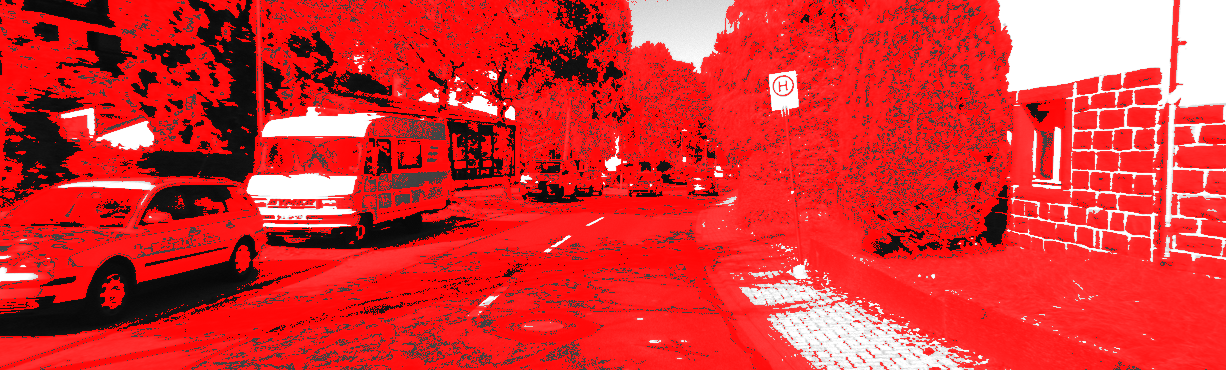

프레임 001224


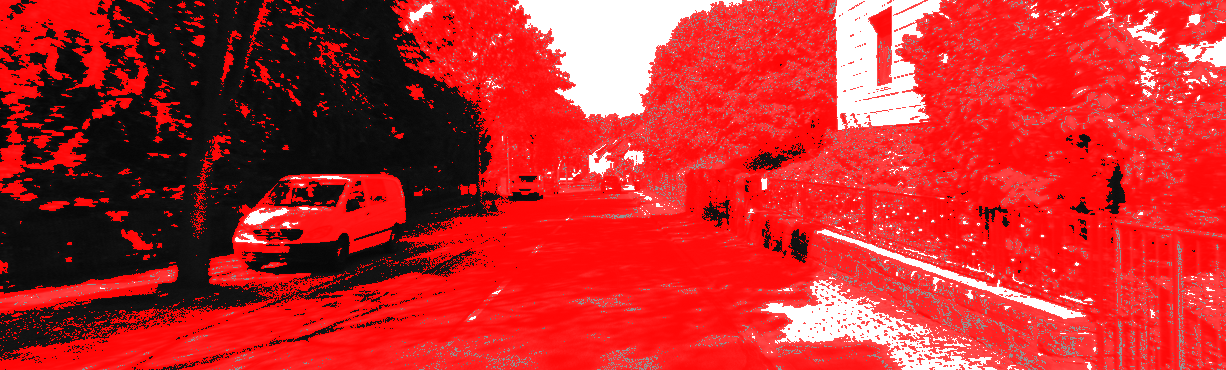

In [18]:
from IPython.display import display
from PIL import Image

# 실패 구간 프레임 확인
for frame_num in ['001346', '001224']:
    img = Image.open(f'/content/outputs/bayes_road/overlay_{frame_num}.png')
    print(f'프레임 {frame_num}')
    display(img)

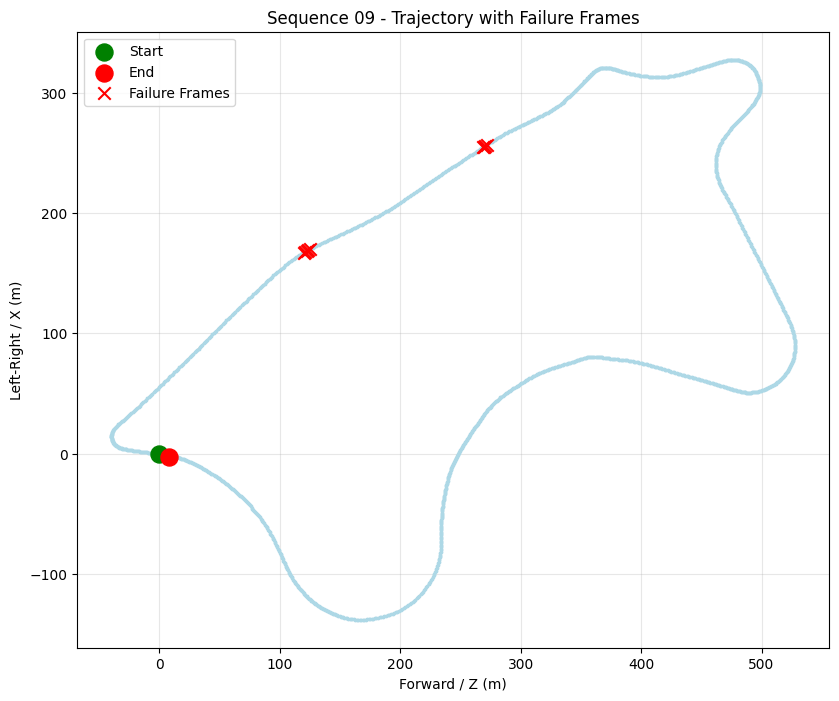

In [20]:
import numpy as np
import matplotlib.pyplot as plt

poses = []
with open('/content/drive/MyDrive/mid_term/09.txt', 'r') as f:
    for line in f.readlines():
        T = np.fromstring(line, dtype=float, sep=' ')
        T = T.reshape(3, 4)
        poses.append(T)

positions = np.array([p[:, 3] for p in poses])
origin = positions[0].copy()
positions = positions - origin

x = positions[:, 0]
z = positions[:, 2]

# 실패 구간 프레임 번호
fail_frames = [1224, 1225, 1226, 1227, 1343, 1344, 1345, 1346, 1347]

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(z, x, color='gray', linewidth=1, alpha=0.5, zorder=2)
ax.scatter(z, x, c='lightblue', s=3, zorder=3)
ax.scatter(z[0], x[0], color='green', s=150, zorder=5, label='Start')
ax.scatter(z[-1], x[-1], color='red', s=150, zorder=5, label='End')

# 실패 구간 표시
ax.scatter(z[fail_frames], x[fail_frames],
           color='red', s=80, zorder=6, label='Failure Frames', marker='x')

ax.set_xlabel('Forward / Z (m)')
ax.set_ylabel('Left-Right / X (m)')
ax.set_title('Sequence 09 - Trajectory with Failure Frames')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.savefig('trajectory_failure.png', dpi=150, bbox_inches='tight')
plt.show()

**1. 실패 구간 선정**

전체 프레임(1,591장)을 대상으로 이미지 내 도로(빨간색 픽셀) 검출 비율을 코드로 정량 분석한 결과, 평균 도로 검출 비율은 36.7%로 나타났다. 하지만 특정 구간에서 도로 검출 비율이 비정상적으로 치솟는 심각한 과검출(Over-detection) 현상이 확인되었으며, 이를 대표적인 실패 구간으로 선정하였다.

| 구간 | 프레임 번호 | 도로 검출 비율 | 비고 |
| :---: | :---: | :---: | :--- |
| **구간 A** | 1343 ~ 1347 | 64.0% ~ 71.6% | 가장 심한 과검출 구간 (최대 71.6%) |
| **구간 B** | 1224 ~ 1227 | 61.1% ~ 65.3% | 두 번째로 심한 과검출 구간 |

<br>

**2. 궤적 상 실패 위치**

위에서 추출한 실패 구간을 2D 탑뷰(Top-view) 궤적 그래프 상에 빨간색 'X'로 표시하여 확인하였다.

구간 B (프레임 1224~1227): $Z \approx 130m, X \approx 165m$ 부근의 좌회전 코너링 진입 구간이다.

구간 A (프레임 1343~1347): $Z \approx 270m, X \approx 255m$ 부근의 거대한 커브 주행 구간에 해당한다.

두 구간 모두 직선 주행로가 아닌, 차량의 회전이 수반되는 곡선 구간이라는 공통적인 공간적 특성을 가진다.

<br>

**3. 실패 원인 분석**

첨부한 프레임 1346 및 1224 이미지를 분석해 보면, 실제 도로뿐만 아니라 건물 외벽, 주차된 차량, 나무, 보도블록 등 배경 영역 전반이 도로로 오분류되어 온통 붉게 표시된 것을 확인할 수 있다. 이러한 극단적인 분류 실패의 원인은 다음과 같이 4가지로 요약할 수 있다.

① 조명 변화 및 강한 그림자 (조명 환경적 요인)
해당 구간의 원본 이미지를 보면 직사광선으로 인해 도로 표면 일부가 하얗게 포화(Saturation)되어 있으며, 가로수 등에 의해 짙은 그림자가 넓게 드리워져 있어 도로의 밝기 분포가 매우 불균일하다. 본 과제의 Bayesian 분류기는 오직 1D 픽셀 밝기 히스토그램에만 의존하기 때문에, 이처럼 강한 조명 변화로 도로와 배경의 밝기 분포가 겹치게 되면 치명적인 오분류가 발생한다.

② 도로 질감 변화 (환경적 요인)
프레임 1346에서는 아스팔트뿐만 아니라 보도블록, 벽돌담, 흙길 등 다양한 질감의 배경이 등장한다. 흑백 이미지 특성상 이러한 재질들은 아스팔트와 유사한 밝기(Intensity) 값을 가질 수 있어, 분류기가 이를 모두 도로로 오인하게 된다.

③ 차량 회전 및 ROI의 한계 (기하학적 요인)
코너링 구간에서는 차량이 회전함에 따라 실제 도로 영역이 화면의 좌측이나 우측으로 크게 휘어지게 된다. 하지만 본 알고리즘의 도로 후보 영역(ROI)은 항상 이미지 중앙 하단을 기준으로 하는 고정된 사다리꼴 형태를 띠고 있다. 따라서 차량 회전 시 실제 도로가 ROI를 벗어나고, 반대로 인도나 건물이 ROI 안으로 들어오면서 초기 확률 분포($Prior$)가 크게 왜곡되는 한계를 지닌다.

④ 시계열 일관성의 누적 오류 (알고리즘적 요인)
본 코드에는 이전 프레임의 통계를 85%($\alpha=0.85$) 반영하는 시계열 일관성(Temporal Consistency) 기법이 적용되어 있다. 이는 정상적인 직진 주행 시에는 노이즈를 줄여주지만, 코너 진입 직전에 위와 같은 이유로 한 번 오분류가 크게 발생할 경우, 그 "잘못된 배경 확률 분포"가 다음 프레임으로 계속 누적되어 전달된다. 결과적으로 한 번 시작된 오분류가 연쇄 작용을 일으켜 특정 구간 전체가 과검출되는 현상으로 이어진 것이다.

결론적으로, 본 실험 결과는 단순 intensity 기반 Bayesian 모델이 실제 환경의 복잡한 조명 및 질감 변화를 충분히 반영하지 못함을 보여준다.

# 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 비교

In [1]:
!pip install transformers

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/14.9M [00:00<?, ?B/s]

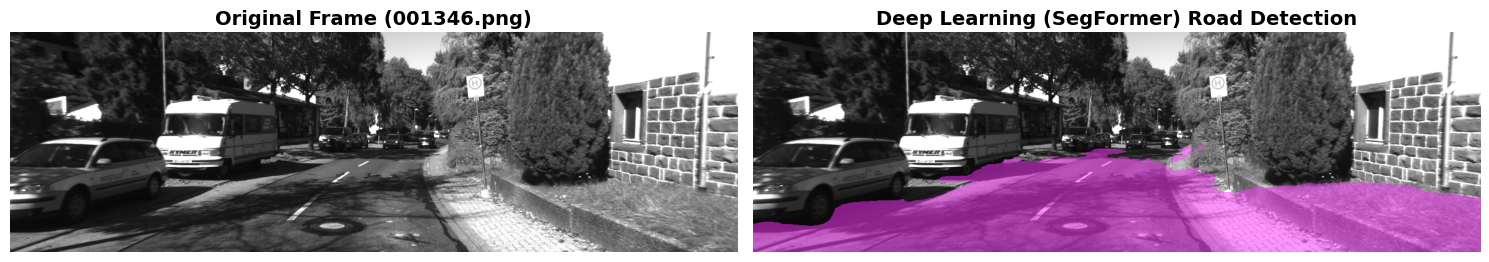

In [2]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

def run_deep_learning_segmentation(image_path):
    # 1. 모델 로드 (Cityscapes 자율주행 데이터셋으로 사전 학습된 모델)

    processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
    model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-1024-1024")

    # 2. 이미지 로드
    image = Image.open(image_path).convert("RGB")

    # 3. 추론 (Inference)

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    # 4. 결과 처리
    logits = outputs.logits
    upsampled_logits = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1], # (height, width)
        mode="bilinear",
        align_corners=False,
    )
    predictions = upsampled_logits.argmax(dim=1)[0].numpy()


    road_mask = (predictions == 0).astype(np.uint8)

    # 5. 시각화 (원본 이미지 위에 도로 영역을 칠하기)
    plt.figure(figsize=(15, 6))

    # (A) 원본 이미지
    plt.subplot(1, 2, 1)
    frame_name = str(image_path).split('/')[-1]
    plt.title(f"Original Frame ({frame_name})", fontsize=14, fontweight='bold')
    plt.imshow(image)
    plt.axis("off")

    # (B) 딥러닝 결과
    plt.subplot(1, 2, 2)
    plt.title("Deep Learning (SegFormer) Road Detection", fontsize=14, fontweight='bold')


    img_arr = np.array(image)
    overlay = img_arr.copy()


    overlay[road_mask == 1, 0] = 255  # R
    overlay[road_mask == 1, 1] = 50   # G
    overlay[road_mask == 1, 2] = 255  # B

    alpha = 0.5 # 투명도 설정
    blended = cv2.addWeighted(img_arr, 1 - alpha, overlay, alpha, 0)

    plt.imshow(blended)
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("deep_learning_result.png", dpi=150)
    plt.show()

# ── 실행 ──

target_frame_path = '/content/drive/MyDrive/mid_term/image_0/001346.png'
run_deep_learning_segmentation(target_frame_path)

**1. 제안하는 딥러닝 모델: SegFormer (Semantic Segmentation)**

본 과제의 픽셀 밝기 기반 Bayesian 분류기가 가지는 한계를 극복하기 위해, 자율주행 환경(Cityscapes 데이터셋)으로 사전 학습된 최신 Transformer 기반 분할 모델인 SegFormer를 제안한다.

SegFormer는 이미지를 패치(Patch) 단위로 분할하여 전체 이미지의 전역적인 문맥(Global Context)을 파악하는 데 강점을 가지며, 픽셀 단위의 의미론적 분할(Semantic Segmentation)을 수행하여 객체들을 구분할 수 있는 모델이다.

<br>

**2. 기존 모델(Bayesian)과의 기술적 비교 및 한계 극복**

앞선 문제 5번에서 분석한 Bayesian 모델의 실패 원인들을 딥러닝 모델(SegFormer)이 어떻게 완화할 수 있는지 비교하면 다음과 같다.

① 조명 변화 및 그림자에 대한 강건함 (Feature Extraction)
Bayesian 모델은 1D 픽셀 밝기 값만을 사용하므로 그림자나 빛 반사 포화 현상에 매우 취약했다. 반면, 딥러닝 모델은 단순 밝기가 아닌 주변 픽셀들과의 관계, 모서리(Edge), 질감(Texture) 등 고차원적인 피처(Deep Feature)를 추출하므로 짙은 그림자 속에서도 도로의 특성을 보다 유연하게 인지할 수 있다.

② 공간적 문맥 이해를 통한 질감 오분류 방지 (Spatial Context)
Bayesian 모델은 건물 벽면이나 보도블록의 밝기가 아스팔트와 비슷하면 도로로 오분류하였다. 그러나 딥러닝은 수많은 학습 데이터를 통해 객체 간의 공간적/형태적 문맥(Spatial Context)을 학습하므로, 밝기나 질감이 비슷하더라도 수직적 구조물(건물 벽돌, 나무)이나 차량 픽셀을 도로로 오분류할 확률이 현저히 낮아진다.

③ 기하학적 형태의 제약 완화 (Free from static ROI)
코너링 구간에서 고정된 사다리꼴 ROI를 벗어나면 검출에 실패했던 기존 모델과 달리, 딥러닝 모델은 이미지 전체(Global Receptive Field)를 입력으로 받아 추론을 수행한다. 따라서 차량이 회전하여 도로가 화면 측면에 나타나는 곡선 구간에서도 동적으로 도로 영역을 분할해 낼 수 있다.

<br>

**3. 적용 결과 비교**

실제 Bayesian 모델이 극심한 과검출을 일으켰던 실패 구간(프레임 001346)에 제안한 SegFormer 모델을 적용하여 결과를 비교하였다.


기존 Bayesian 모델은 짙은 그림자, 하얀색 밴 차량, 우측의 건물 벽돌의 밝기 분포를 아스팔트와 구분하지 못하고 화면 상당 부분을 도로로 오분류하는 한계를 보였다. 반면, 제안한 SegFormer 모델은 강한 그림자의 유무나 구조물의 표면 질감에 큰 영향을 받지 않고 이미지 내에서 '주행 가능한 도로' 영역을 분할함에 있어 오분류가 크게 감소하였으며, 상대적으로 안정적인 결과를 보였다.

결론적으로, 1D 통계 모델만으로는 복잡한 조명과 구조물이 혼재된 도심지 환경(Sequence 09)을 인식하는 데 한계가 존재하며, 자율주행 시스템의 인지 성능을 향상하기 위해서는 주변 환경의 형태적 문맥을 종합적으로 고려할 수 있는 딥러닝 기반 모델의 도입이 효과적인 대안이 될 수 있음을 확인하였다.